<a href="https://colab.research.google.com/github/SohamB1810/Recomendation_system/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
movies = pd.read_csv('/content/tmdb_5000_movies.csv')
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [3]:
credits = pd.read_csv('/content/tmdb_5000_credits.csv')
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [4]:
movies_df = movies.merge(credits, on='title')
movies_df.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [5]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   object 
 2   homepage              1713 non-null   object 
 3   id                    4809 non-null   int64  
 4   keywords              4809 non-null   object 
 5   original_language     4809 non-null   object 
 6   original_title        4809 non-null   object 
 7   overview              4806 non-null   object 
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   object 
 10  production_countries  4809 non-null   object 
 11  release_date          4808 non-null   object 
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   object 
 15  status               

In [6]:
movies_clean_df = movies_df.drop(columns=['budget', 'homepage','original_language','original_title','production_companies','production_countries','revenue','runtime','spoken_languages','status','tagline','movie_id'])
movies_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   genres        4809 non-null   object 
 1   id            4809 non-null   int64  
 2   keywords      4809 non-null   object 
 3   overview      4806 non-null   object 
 4   popularity    4809 non-null   float64
 5   release_date  4808 non-null   object 
 6   title         4809 non-null   object 
 7   vote_average  4809 non-null   float64
 8   vote_count    4809 non-null   int64  
 9   cast          4809 non-null   object 
 10  crew          4809 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 413.4+ KB


In [7]:
movies_clean_df.dropna(inplace=True)
movies_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4805 entries, 0 to 4808
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   genres        4805 non-null   object 
 1   id            4805 non-null   int64  
 2   keywords      4805 non-null   object 
 3   overview      4805 non-null   object 
 4   popularity    4805 non-null   float64
 5   release_date  4805 non-null   object 
 6   title         4805 non-null   object 
 7   vote_average  4805 non-null   float64
 8   vote_count    4805 non-null   int64  
 9   cast          4805 non-null   object 
 10  crew          4805 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 450.5+ KB


In [8]:

movies_clean_df.head()

,genres,id,keywords,overview,popularity,release_date,title,vote_average,vote_count,cast,crew
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",A cryptic message from Bond’s past sends him o...,107.376788,2015-10-26,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",Following the death of District Attorney Harve...,112.312950,2012-07-16,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","John Carter is a war-weary, former military ca...",43.926995,2012-03-07,John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [9]:
import ast

In [10]:
def convert(text):
    L=[]
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L

In [11]:
movies_clean_df['genres'] = movies_clean_df['genres'].apply(convert)
movies_clean_df.head()

,genres,id,keywords,overview,popularity,release_date,title,vote_average,vote_count,cast,crew
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,"[Adventure, Fantasy, Action]",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,"[Action, Adventure, Crime]",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",A cryptic message from Bond’s past sends him o...,107.376788,2015-10-26,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,"[Action, Crime, Drama, Thriller]",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",Following the death of District Attorney Harve...,112.312950,2012-07-16,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,"[Action, Adventure, Science Fiction]",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","John Carter is a war-weary, former military ca...",43.926995,2012-03-07,John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [12]:
movies_clean_df['keywords'] = movies_clean_df['keywords'].apply(convert)
movies_clean_df.head()

,genres,id,keywords,overview,popularity,release_date,title,vote_average,vote_count,cast,crew
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",A cryptic message from Bond’s past sends him o...,107.376788,2015-10-26,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",Following the death of District Attorney Harve...,112.312950,2012-07-16,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...","John Carter is a war-weary, former military ca...",43.926995,2012-03-07,John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [13]:
def convert(text):
    L=[]
    counter = 0
    for i in ast.literal_eval(text):
        if counter < 3:
           L.append(i['name'])
        counter +=1
    return L

In [14]:
movies_clean_df['cast']=movies_clean_df['cast'].apply(convert)
movies_clean_df.head()

,genres,id,keywords,overview,popularity,release_date,title,vote_average,vote_count,cast,crew
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,Avatar,7.2,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,Pirates of the Caribbean: At World's End,6.9,4500,"[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",A cryptic message from Bond’s past sends him o...,107.376788,2015-10-26,Spectre,6.3,4466,"[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",Following the death of District Attorney Harve...,112.312950,2012-07-16,The Dark Knight Rises,7.6,9106,"[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...","John Carter is a war-weary, former military ca...",43.926995,2012-03-07,John Carter,6.1,2124,"[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [15]:
def convert(text):
    L=[]
    for i in ast.literal_eval(text):
        if i['job']=='Director':
            L.append(i['name'])
    return L

In [16]:
movies_clean_df['crew'] = movies_clean_df['crew'].apply(convert)
movies_clean_df.rename(columns={'crew': 'director'}, inplace=True)
movies_clean_df.head()

,genres,id,keywords,overview,popularity,release_date,title,vote_average,vote_count,cast,director
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,Avatar,7.2,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,Pirates of the Caribbean: At World's End,6.9,4500,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",A cryptic message from Bond’s past sends him o...,107.376788,2015-10-26,Spectre,6.3,4466,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",Following the death of District Attorney Harve...,112.312950,2012-07-16,The Dark Knight Rises,7.6,9106,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...","John Carter is a war-weary, former military ca...",43.926995,2012-03-07,John Carter,6.1,2124,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [17]:
movies_clean_df = pd.DataFrame(movies_clean_df)
movies_clean_df['release_date'] = pd.to_datetime(movies_clean_df['release_date']).dt.year

In [18]:
movies_clean_df.head()

,genres,id,keywords,overview,popularity,release_date,title,vote_average,vote_count,cast,director
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009,Avatar,7.2,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...",139.082615,2007,Pirates of the Caribbean: At World's End,6.9,4500,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",A cryptic message from Bond’s past sends him o...,107.376788,2015,Spectre,6.3,4466,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",Following the death of District Attorney Harve...,112.312950,2012,The Dark Knight Rises,7.6,9106,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...","John Carter is a war-weary, former military ca...",43.926995,2012,John Carter,6.1,2124,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [19]:
v = movies_clean_df['vote_count']
R = movies_clean_df['vote_average']
C = movies_clean_df['vote_average'].mean()
m = movies_clean_df['vote_count'].quantile(0.85)

In [20]:
movies_clean_df['weighted_average'] = ((R*v)+(C*m))/(v+m)
movies_clean_df.head()

,genres,id,keywords,overview,popularity,release_date,title,vote_average,vote_count,cast,director,weighted_average
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009,Avatar,7.2,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron],7.089977
1,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...",139.082615,2007,Pirates of the Caribbean: At World's End,6.9,4500,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski],6.719011
2,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",A cryptic message from Bond’s past sends him o...,107.376788,2015,Spectre,6.3,4466,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes],6.253558
3,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",Following the death of District Attorney Harve...,112.312950,2012,The Dark Knight Rises,7.6,9106,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan],7.411393
4,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...","John Carter is a war-weary, former military ca...",43.926995,2012,John Carter,6.1,2124,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton],6.097918


In [21]:
movie_ranked = movies_clean_df.sort_values('weighted_average',ascending=False)
movie_ranked[['title','genres','vote_count','vote_average','weighted_average','popularity']].head(25)

,title,genres,vote_count,vote_average,weighted_average,popularity
1883,The Shawshank Redemption,"[Drama, Crime]",8205,8.5,8.170086,136.747729
662,Fight Club,[Drama],9413,8.3,8.031611,146.757391
3235,Pulp Fiction,"[Thriller, Crime]",8428,8.3,8.004447,121.463076
65,The Dark Knight,"[Drama, Action, Crime, Thriller]",12002,8.2,7.993633,187.322927
3340,The Godfather,"[Drama, Crime]",5893,8.4,7.982227,143.659698
96,Inception,"[Action, Thriller, Science Fiction, Mystery, A...",13752,8.1,7.926282,167.583710
809,Forrest Gump,"[Comedy, Drama, Romance]",7927,8.2,7.902535,138.133331
95,Interstellar,"[Adventure, Drama, Science Fiction]",10867,8.1,7.885104,724.247784
329,The Lord of the Rings: The Return of the King,"[Adventure, Fantasy, Action]",8064,8.1,7.820807,123.630332
1992,The Empire Strikes Back,"[Adventure, Action, Science Fiction]",5879,8.2,7.817725,78.517830


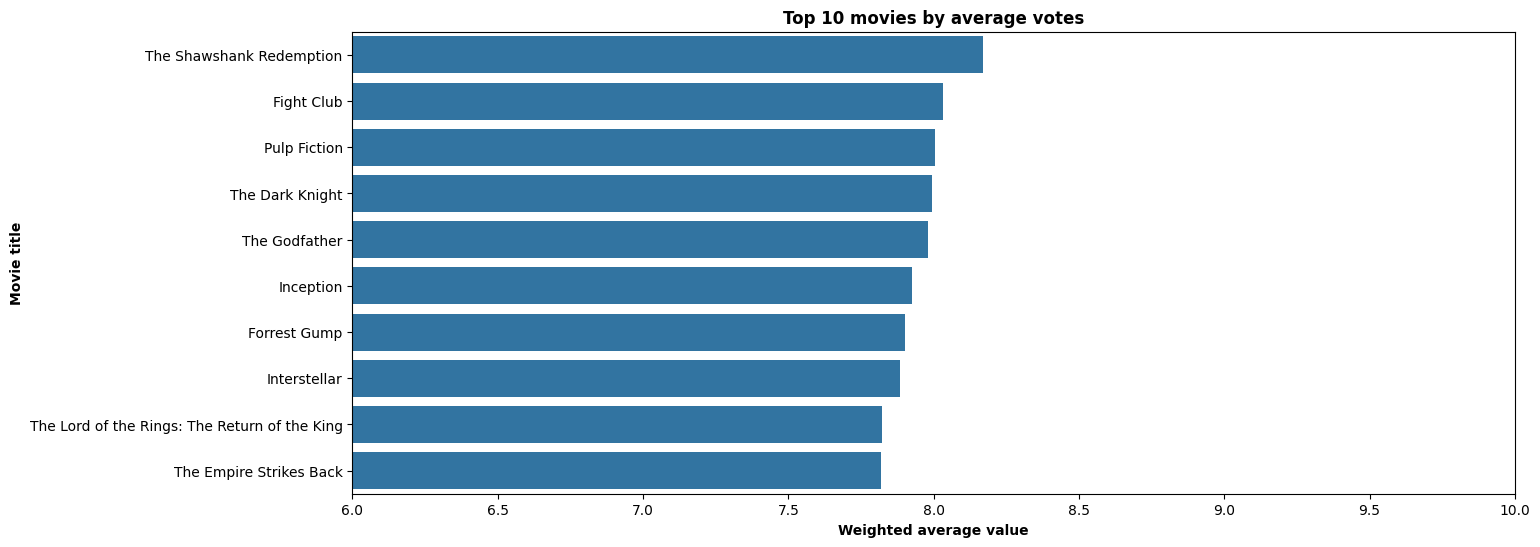

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

weighted_average = movie_ranked.sort_values('weighted_average',ascending=False)
plt.figure(figsize=(15,6))
axsis1=sns.barplot(x=weighted_average['weighted_average'].head(10),y=weighted_average['title'].head(10),data=weighted_average)
plt.xlim(6,10)
plt.title('Top 10 movies by average votes',weight='bold')
plt.xlabel('Weighted average value',weight='bold')
plt.ylabel('Movie title',weight='bold')
plt.savefig('top_10.png')

In [23]:
movie_ranked = movies_clean_df.sort_values('popularity',ascending=False)
movie_ranked[['title','genres','vote_count','vote_average','weighted_average','popularity']].head(25)

,title,genres,vote_count,vote_average,weighted_average,popularity
546,Minions,"[Family, Animation, Adventure, Comedy]",4571,6.4,6.332190,875.581305
95,Interstellar,"[Adventure, Drama, Science Fiction]",10867,8.1,7.885104,724.247784
788,Deadpool,"[Action, Adventure, Comedy]",10995,7.4,7.261568,514.569956
94,Guardians of the Galaxy,"[Action, Science Fiction, Adventure]",9742,7.9,7.686832,481.098624
127,Mad Max: Fury Road,"[Action, Adventure, Science Fiction, Thriller]",9427,7.2,7.065648,434.278564
28,Jurassic World,"[Action, Adventure, Science Fiction, Thriller]",8662,6.5,6.446939,418.708552
199,Pirates of the Caribbean: The Curse of the Bla...,"[Adventure, Fantasy, Action]",6985,7.5,7.278867,271.972889
82,Dawn of the Planet of the Apes,"[Science Fiction, Action, Drama, Thriller]",4410,7.3,7.024865,243.791743
200,The Hunger Games: Mockingjay - Part 1,"[Science Fiction, Adventure, Thriller]",5584,6.6,6.504295,206.227151
88,Big Hero 6,"[Adventure, Family, Animation, Action, Comedy]",6135,7.8,7.501006,203.734590


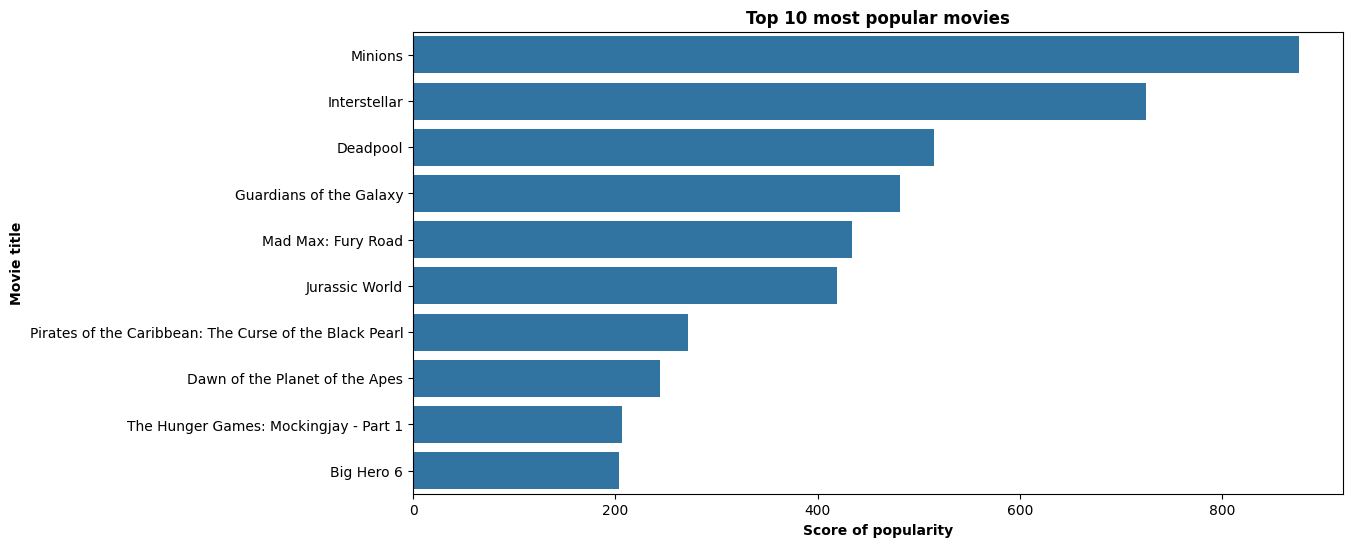

In [24]:
popularity = movie_ranked.sort_values('popularity',ascending=False)
plt.figure(figsize=(12,6))
axsis1=sns.barplot(x=popularity['popularity'].head(10),y=popularity['title'].head(10),data=popularity)

plt.title('Top 10 most popular movies',weight='bold')
plt.xlabel('Score of popularity',weight='bold')
plt.ylabel('Movie title',weight='bold')
plt.savefig('best_popular_10.png')

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaling=MinMaxScaler()
movie_scaled_df=scaling.fit_transform(movies_clean_df[['weighted_average','popularity']])
movie_normalized_df=pd.DataFrame(movie_scaled_df,columns=['weighted_average','popularity'])
movie_normalized_df.head()

,weighted_average,popularity
0,0.657451,0.171814
1,0.539801,0.158846
2,0.392186,0.122634
3,0.759385,0.128272
4,0.342825,0.050169


In [26]:
movies_clean_df[['normalized_weight_average','normalized_popularity']]=movie_normalized_df
movies_clean_df.head()

,genres,id,keywords,overview,popularity,release_date,title,vote_average,vote_count,cast,director,weighted_average,normalized_weight_average,normalized_popularity
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009,Avatar,7.2,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron],7.089977,0.657451,0.171814
1,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...",139.082615,2007,Pirates of the Caribbean: At World's End,6.9,4500,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski],6.719011,0.539801,0.158846
2,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",A cryptic message from Bond’s past sends him o...,107.376788,2015,Spectre,6.3,4466,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes],6.253558,0.392186,0.122634
3,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",Following the death of District Attorney Harve...,112.312950,2012,The Dark Knight Rises,7.6,9106,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan],7.411393,0.759385,0.128272
4,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...","John Carter is a war-weary, former military ca...",43.926995,2012,John Carter,6.1,2124,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton],6.097918,0.342825,0.050169


In [27]:
movies_clean_df['score'] = movies_clean_df['normalized_weight_average']*0.5 + movies_clean_df['normalized_popularity']*0.5
movie_scored_df = movies_clean_df.sort_values(['score'],ascending=False)
movie_scored_df[['title','release_date','normalized_weight_average','normalized_popularity','score']].head(25)

,title,release_date,normalized_weight_average,normalized_popularity,score
95,Interstellar,2014,0.909620,0.827162,0.868391
546,Minions,2015,0.417123,1.000000,0.708562
94,Guardians of the Galaxy,2014,0.846739,0.549462,0.698100
788,Deadpool,2016,0.711869,0.587689,0.649779
65,The Dark Knight,2008,0.944039,0.213941,0.578990
1883,The Shawshank Redemption,1994,1.000000,0.156179,0.578090
127,Mad Max: Fury Road,2015,0.649735,0.495989,0.572862
662,Fight Club,1999,0.956084,0.167611,0.561847
96,Inception,2010,0.922679,0.191397,0.557038
3339,Diamonds Are Forever,1971,0.940422,0.164073,0.552247


/tmp/ipython-input-2023093549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  axsis1=sns.barplot(x=scored_df['score'].head(10),y=scored_df['title'].head(10),data=scored_df, palette='deep')


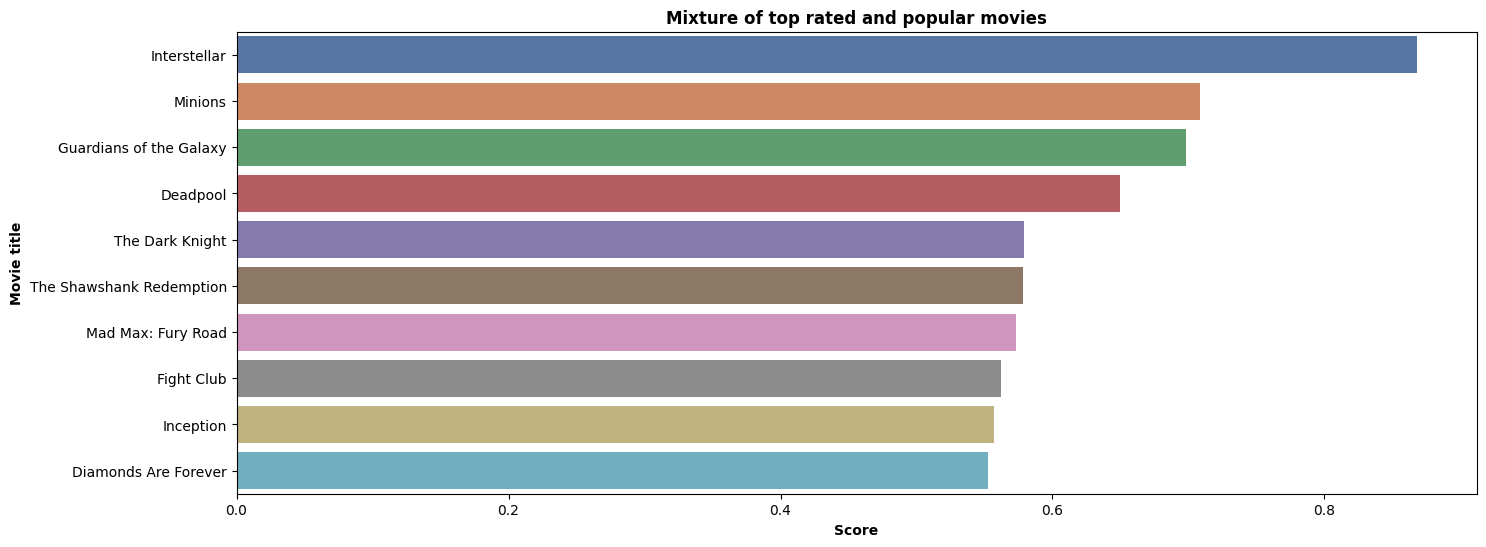

In [28]:
scored_df = movies_clean_df.sort_values('score',ascending=False)
plt.figure(figsize=(16,6))
axsis1=sns.barplot(x=scored_df['score'].head(10),y=scored_df['title'].head(10),data=scored_df, palette='deep')

plt.title('Mixture of top rated and popular movies',weight='bold')
plt.xlabel('Score',weight='bold')
plt.ylabel('Movie title',weight='bold')
plt.savefig('scored_mvies_10.png')

In [30]:
s = movie_scored_df.apply(lambda x: pd.Series(x['genres']),axis=1).stack().reset_index(level=1, drop=True)
s.name = 'genre'

gen_movie_scored_df = movie_scored_df.drop('genres', axis=1).join(s)

In [31]:
def build_chart(genre, percentile=0.85):

    df = gen_movie_scored_df[gen_movie_scored_df['genre'] == genre]


    selected_columns = ['title', 'release_date', 'score', 'weighted_average', 'popularity']
    df = df[selected_columns]


    df = df.sort_values('score', ascending=False).head(250)

    return df

In [32]:
recommended_movies = build_chart('Action')  # Replace 'Action' with the desired genre
recommended_movies.head(25)

,title,release_date,score,weighted_average,popularity
94,Guardians of the Galaxy,2014,0.698100,7.686832,481.098624
788,Deadpool,2016,0.649779,7.261568,514.569956
65,The Dark Knight,2008,0.578990,7.993633,187.322927
127,Mad Max: Fury Road,2015,0.572862,7.065648,434.278564
96,Inception,2010,0.557038,7.926282,167.583710
3339,Diamonds Are Forever,1971,0.552247,6.155708,34.634181
3234,Valley of the Wolves: Iraq,2006,0.543096,6.084946,1.465762
329,The Lord of the Rings: The Return of the King,2003,0.515213,7.820807,123.630332
199,Pirates of the Caribbean: The Curse of the Bla...,2003,0.513988,7.278867,271.972889
262,The Lord of the Rings: The Fellowship of the Ring,2001,0.512491,7.751717,138.049577


In [33]:
recommended_movies = build_chart('Romance')
recommended_movies.head(25)

,title,release_date,score,weighted_average,popularity
809,Forrest Gump,1994,0.536455,7.902535,138.133331
3160,Jab Tak Hai Jaan,2012,0.446291,6.152592,5.900535
3456,The Wood,1999,0.434458,6.120073,5.537646
2761,Woo,1998,0.424515,6.090003,1.750054
1999,Her,2013,0.418696,7.464042,53.682367
25,Titanic,1997,0.418079,7.293258,100.025899
2154,Eternal Sunshine of the Spotless Mind,2004,0.414088,7.424898,56.481487
1261,Amélie,2001,0.406973,7.317949,73.720244
4341,Tom Jones,1963,0.403989,6.094685,2.833166
2549,The Theory of Everything,2014,0.399830,7.318054,61.182331


In [34]:
recommended_movies = build_chart('Horror')
recommended_movies.head(25)

,title,release_date,score,weighted_average,popularity
2914,Gremlins,1984,0.508750,6.537784,45.072136
2286,The Shining,1980,0.451881,7.583218,78.699993
3575,The Lazarus Effect,2015,0.445775,5.816925,20.304235
2172,Psycho,1960,0.437744,7.442327,93.067866
2968,Darkness,2002,0.419607,6.055417,6.340135
2753,The Mist,2007,0.412387,6.407880,37.104353
2405,Aliens,1986,0.390706,7.237187,67.660940
3944,Tusk,2014,0.384162,5.876591,15.754614
1319,The Thing,1982,0.349475,7.030939,52.731379
2810,The Exorcist,1973,0.346811,6.946084,47.584643


In [35]:
movie_cb = movies_clean_df[['id','title','genres','keywords','overview','cast','director']]
movie_cb.head(10)

,id,title,genres,keywords,overview,cast,director
0,19995,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...",A cryptic message from Bond’s past sends him o...,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...",Following the death of District Attorney Harve...,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","John Carter is a war-weary, former military ca...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]
5,559,Spider-Man 3,"[Fantasy, Action, Adventure]","[dual identity, amnesia, sandstorm, love of on...",The seemingly invincible Spider-Man goes up ag...,"[Tobey Maguire, Kirsten Dunst, James Franco]",[Sam Raimi]
6,38757,Tangled,"[Animation, Family]","[hostage, magic, horse, fairy tale, musical, p...",When the kingdom's most wanted-and most charmi...,"[Zachary Levi, Mandy Moore, Donna Murphy]","[Byron Howard, Nathan Greno]"
7,99861,Avengers: Age of Ultron,"[Action, Adventure, Science Fiction]","[marvel comic, sequel, superhero, based on com...",When Tony Stark tries to jumpstart a dormant p...,"[Robert Downey Jr., Chris Hemsworth, Mark Ruff...",[Joss Whedon]
8,767,Harry Potter and the Half-Blood Prince,"[Adventure, Fantasy, Family]","[witch, magic, broom, school of witchcraft, wi...","As Harry begins his sixth year at Hogwarts, he...","[Daniel Radcliffe, Rupert Grint, Emma Watson]",[David Yates]
9,209112,Batman v Superman: Dawn of Justice,"[Action, Adventure, Fantasy]","[dc comics, vigilante, superhero, based on com...",Fearing the actions of a god-like Super Hero l...,"[Ben Affleck, Henry Cavill, Gal Gadot]",[Zack Snyder]


In [36]:
def collaspe(L):
    L1=[]
    for i in L:
        L1.append(i.replace(" ",""))
    return L1

In [37]:
movie_cb.loc[:,'cast'] = movie_cb['cast'].apply(collaspe)
movie_cb.loc[:,'director'] = movie_cb['director'].apply(collaspe)
movie_cb.loc[:,'genres'] = movie_cb['genres'].apply(collaspe)
movie_cb.loc[:,'keywords'] = movie_cb['keywords'].apply(collaspe)

movie_cb.head(10)

,id,title,genres,keywords,overview,cast,director
0,19995,Avatar,"[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","In the 22nd century, a paraplegic Marine is di...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron]
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","Captain Barbossa, long believed to be dead, ha...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski]
2,206647,Spectre,"[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...",A cryptic message from Bond’s past sends him o...,"[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes]
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...",Following the death of District Attorney Harve...,"[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan]
4,49529,John Carter,"[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","John Carter is a war-weary, former military ca...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton]
5,559,Spider-Man 3,"[Fantasy, Action, Adventure]","[dualidentity, amnesia, sandstorm, loveofone's...",The seemingly invincible Spider-Man goes up ag...,"[TobeyMaguire, KirstenDunst, JamesFranco]",[SamRaimi]
6,38757,Tangled,"[Animation, Family]","[hostage, magic, horse, fairytale, musical, pr...",When the kingdom's most wanted-and most charmi...,"[ZacharyLevi, MandyMoore, DonnaMurphy]","[ByronHoward, NathanGreno]"
7,99861,Avengers: Age of Ultron,"[Action, Adventure, ScienceFiction]","[marvelcomic, sequel, superhero, basedoncomicb...",When Tony Stark tries to jumpstart a dormant p...,"[RobertDowneyJr., ChrisHemsworth, MarkRuffalo]",[JossWhedon]
8,767,Harry Potter and the Half-Blood Prince,"[Adventure, Fantasy, Family]","[witch, magic, broom, schoolofwitchcraft, wiza...","As Harry begins his sixth year at Hogwarts, he...","[DanielRadcliffe, RupertGrint, EmmaWatson]",[DavidYates]
9,209112,Batman v Superman: Dawn of Justice,"[Action, Adventure, Fantasy]","[dccomics, vigilante, superhero, basedoncomicb...",Fearing the actions of a god-like Super Hero l...,"[BenAffleck, HenryCavill, GalGadot]",[ZackSnyder]


In [38]:
movie_cb['overview'] = movie_cb['overview'].apply(lambda x:x.split())

/tmp/ipython-input-1288205498.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_cb['overview'] = movie_cb['overview'].apply(lambda x:x.split())


In [39]:
movie_cb['tags'] = movie_cb['overview']+movie_cb['genres']+movie_cb['keywords']+movie_cb['cast']+movie_cb['director']
tagged_movie = movie_cb.drop(columns=['overview','genres','keywords','cast','director'])
tagged_movie['tags'] = tagged_movie['tags'].apply(lambda x:" ".join(x))
tagged_movie.head(10)

/tmp/ipython-input-4189215866.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_cb['tags'] = movie_cb['overview']+movie_cb['genres']+movie_cb['keywords']+movie_cb['cast']+movie_cb['director']


,id,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...
4,49529,John Carter,"John Carter is a war-weary, former military ca..."
5,559,Spider-Man 3,The seemingly invincible Spider-Man goes up ag...
6,38757,Tangled,When the kingdom's most wanted-and most charmi...
7,99861,Avengers: Age of Ultron,When Tony Stark tries to jumpstart a dormant p...
8,767,Harry Potter and the Half-Blood Prince,"As Harry begins his sixth year at Hogwarts, he..."
9,209112,Batman v Superman: Dawn of Justice,Fearing the actions of a god-like Super Hero l...


In [40]:
tagged_movie['tags']=tagged_movie['tags'].apply(lambda x:x.lower())
tagged_movie.head()

,id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [41]:
tagged_movie['title'].values

array(['Avatar', "Pirates of the Caribbean: At World's End", 'Spectre',
       ..., 'Signed, Sealed, Delivered', 'Shanghai Calling',
       'My Date with Drew'], dtype=object)

In [42]:
import nltk
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [43]:
def stem(text):
    y = []
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

In [44]:
tagged_movie['tags']=tagged_movie['tags'].apply(stem)

In [45]:
tagged_movie['tags'][0]

'in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien tribe alienplanet cgi marin soldier battl loveaffair antiwar powerrel mindandsoul 3d samworthington zoesaldana sigourneyweav jamescameron'

In [47]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000,stop_words='english')

In [48]:
vectors = cv.fit_transform(tagged_movie['tags']).toarray()

In [49]:
from sklearn.metrics.pairwise import cosine_similarity

In [61]:
similarity_matrix = cosine_similarity(vectors)
tagged_movie['similarity'] = similarity_matrix.tolist()

In [60]:
similarity_matrix.shape

(4805, 4805)

In [62]:
def recommend(movie):
    if movie not in tagged_movie['title'].values:
        print(f"Movie '{movie}' not found in the database.")
        return
    index = tagged_movie[tagged_movie['title'] == movie].index[0]
    distance = sorted(list(enumerate(similarity_matrix[index])), reverse=True, key=lambda x: x[1])
    for i in distance[1:6]:
        print(tagged_movie.iloc[i[0]].title)

In [63]:
recommend('Avatar')

Aliens vs Predator: Requiem
Aliens
Falcon Rising
Independence Day
Titan A.E.


In [64]:
recommend('Batman Begins')

The Dark Knight
Batman
Batman
The Dark Knight Rises
10th & Wolf


In [65]:
recommend('Harry Potter')

Movie 'Harry Potter' not found in the database.


In [66]:
recommend("Pirates of the Caribbean: At World's End")

Pirates of the Caribbean: Dead Man's Chest
Pirates of the Caribbean: The Curse of the Black Pearl
Pirates of the Caribbean: On Stranger Tides
Life of Pi
20,000 Leagues Under the Sea


In [67]:
import pickle

In [68]:
with open('popularity_model.pkl', 'wb') as f:
    pickle.dump(movie_scored_df, f)

In [69]:
import pickle
import gzip

In [ ]:
with gzip.open('content_model.pkl.gz', 'wb') as f_content:
    pickle.dump(tagged_movie, f_content)